<a href="https://colab.research.google.com/github/Amulya-Rao-mj/ML2_lab--Amulya-Rao-M-J--4NI23CI013/blob/main/SequentialCovering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
STEP 0 : THE MALL CUSTOMERS DATASET
      Genre AgeCategory IncomeCategory SpendingCategory HighSpender
0      Male       Young            Low              Low          No
1      Male       Young            Low             High         Yes
2    Female       Young            Low              Low          No
3    Female       Young            Low             High         Yes
4    Female       Adult            Low           Medium          No
5    Female       Young            Low             High         Yes
6    Female       Adult            Low      

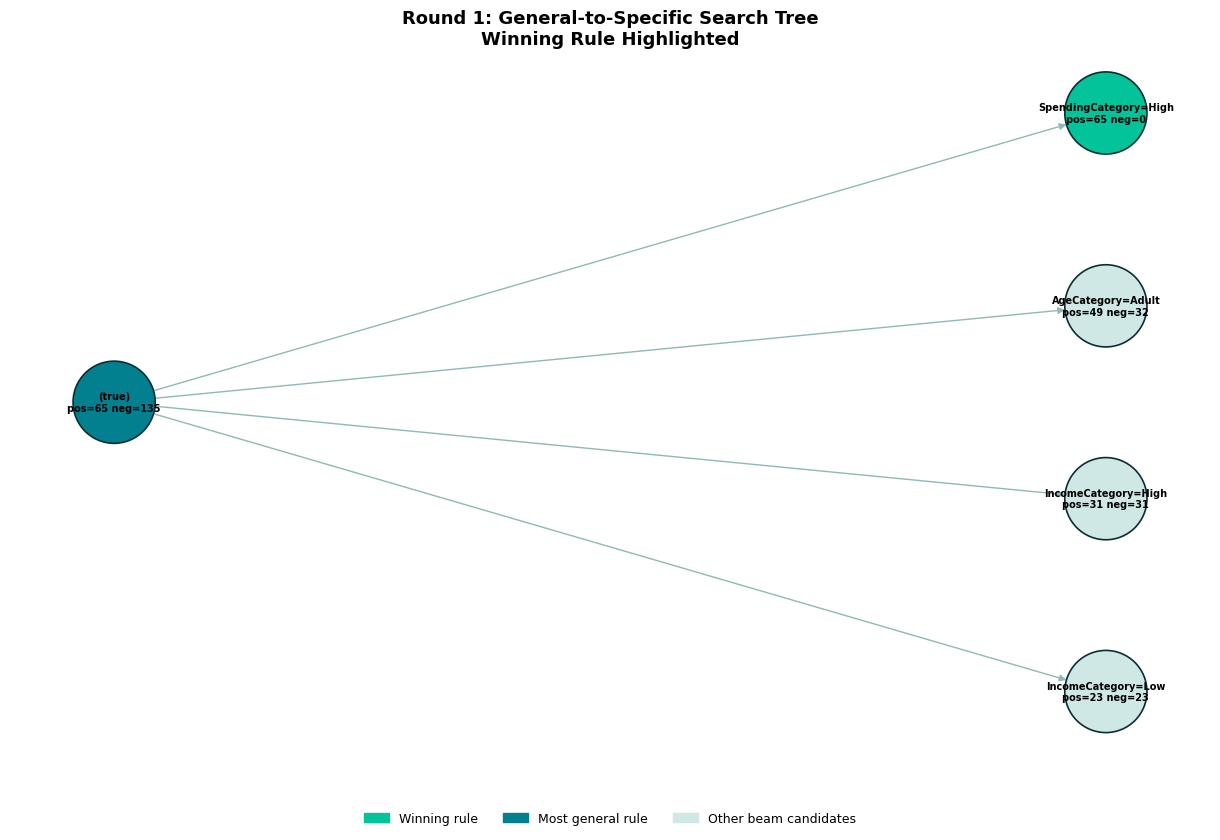

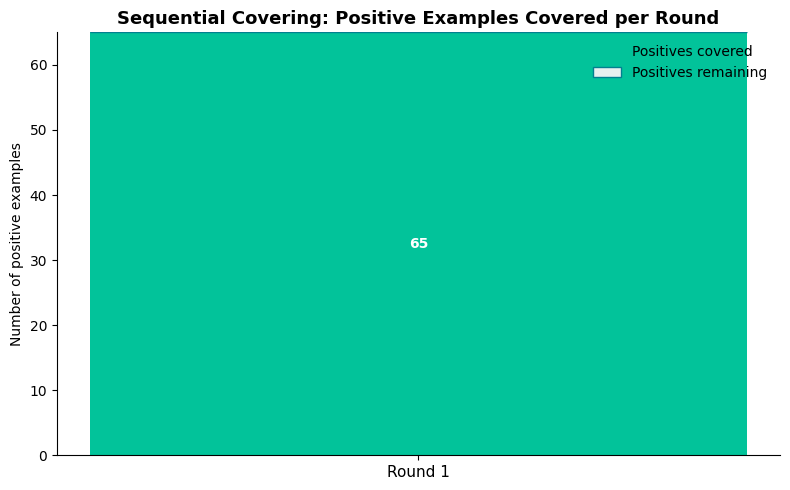

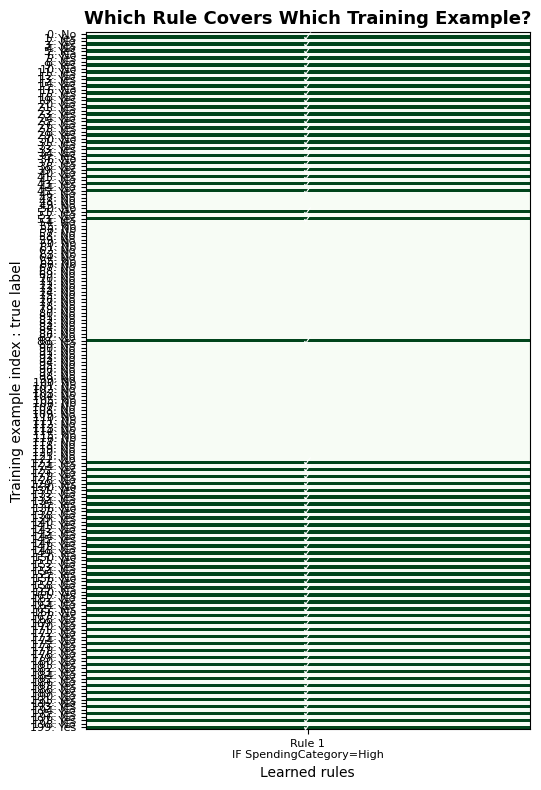

In [1]:
# Install if required:
# pip install networkx pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx


# ------------------------------------------------------------------
# 1. LOAD MALL CUSTOMERS DATASET
# ------------------------------------------------------------------

# Change the filename if your CSV has a different name
df = pd.read_csv("Mall_Customers.csv")

print("Original Dataset:")
print(df.head())


# ------------------------------------------------------------------
# 2. PREPARE THE DATASET
# ------------------------------------------------------------------

# Expected columns:
# CustomerID
# Genre
# Age
# Annual Income (k$)
# Spending Score (1-100)


# Convert numerical attributes into categories
def age_category(age):
    if age < 25:
        return "Young"
    elif age < 40:
        return "Adult"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"


def income_category(income):
    if income < 40:
        return "Low"
    elif income < 70:
        return "Medium"
    elif income < 100:
        return "High"
    else:
        return "VeryHigh"


def spending_category(score):
    if score < 40:
        return "Low"
    elif score < 60:
        return "Medium"
    else:
        return "High"


df["AgeCategory"] = df["Age"].apply(age_category)

df["IncomeCategory"] = df["Annual Income (k$)"].apply(
    income_category
)

df["SpendingCategory"] = df["Spending Score (1-100)"].apply(
    spending_category
)


# ------------------------------------------------------------------
# 3. CREATE TARGET ATTRIBUTE
# ------------------------------------------------------------------

# HighSpender:
# Spending Score >= 60  -> Yes
# Spending Score < 60   -> No

df["HighSpender"] = df["Spending Score (1-100)"].apply(
    lambda x: "Yes" if x >= 60 else "No"
)


# ------------------------------------------------------------------
# 4. ATTRIBUTES USED FOR RULE LEARNING
# ------------------------------------------------------------------

columns = [
    "Genre",
    "AgeCategory",
    "IncomeCategory",
    "SpendingCategory",
    "HighSpender"
]

df_model = df[columns].copy()

TARGET_ATTR = "HighSpender"
TARGET_VAL = "Yes"

ATTRIBUTES = [
    c for c in columns
    if c != TARGET_ATTR
]


# Domain (possible values) of every attribute

DOMAIN = {
    attr: sorted(df_model[attr].unique())
    for attr in ATTRIBUTES
}


# ------------------------------------------------------------------
# 5. PRINT DATASET
# ------------------------------------------------------------------

def print_dataset():

    print("=" * 90)
    print("STEP 0 : THE MALL CUSTOMERS DATASET")
    print("=" * 90)

    print(df_model.to_string(index=True))

    n_pos = (
        df_model[TARGET_ATTR] == TARGET_VAL
    ).sum()

    n_neg = (
        df_model[TARGET_ATTR] != TARGET_VAL
    ).sum()

    print(
        f"\nTotal examples: {len(df_model)}"
        f"   |   High Spender (Yes): {n_pos}"
        f"   |   Not High Spender (No): {n_neg}"
    )

    print()


# ------------------------------------------------------------------
# 6. RULE REPRESENTATION & SCORING
# ------------------------------------------------------------------

# A rule is represented as:
#
# {
#     "Genre": "Female",
#     "IncomeCategory": "High"
# }
#
# Empty dictionary {} means the most general rule.


def covers(rule, row):

    """Does this example satisfy every condition in the rule?"""

    return all(
        row[attr] == val
        for attr, val in rule.items()
    )


def evaluate(rule, examples):

    """
    Return:
        positives covered
        negatives covered
        precision
    """

    covered = examples[
        examples.apply(
            lambda r: covers(rule, r),
            axis=1
        )
    ]

    pos = (
        covered[TARGET_ATTR] == TARGET_VAL
    ).sum()

    neg = (
        covered[TARGET_ATTR] != TARGET_VAL
    ).sum()

    precision = (
        pos / (pos + neg)
        if (pos + neg) > 0
        else 0.0
    )

    return pos, neg, precision


def rule_to_str(rule):

    if not rule:
        return "IF (true)"

    conditions = " AND ".join(
        f"{a}={v}"
        for a, v in rule.items()
    )

    return f"IF {conditions}"


# ------------------------------------------------------------------
# 7. LEARN-ONE-RULE
# GENERAL-TO-SPECIFIC BEAM SEARCH
# ------------------------------------------------------------------

def learn_one_rule(
    examples,
    beam_width=4,
    max_conditions=None
):

    """
    General-to-specific beam search.

    Starts with the most general rule and
    gradually adds attribute=value conditions.
    """

    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)


    search_history = []


    # --------------------------------------------------------------
    # DEPTH 0
    # --------------------------------------------------------------

    beam = [{}]

    depth0_pos, depth0_neg, depth0_prec = evaluate(
        {},
        examples
    )

    search_history.append({

        "depth": 0,

        "candidates": [
            (
                {},
                depth0_pos,
                depth0_neg,
                depth0_prec,
                None
            )
        ],

        "beam": [{}]
    })


    best_rule = {}

    best_pos = depth0_pos

    best_neg = depth0_neg

    best_prec = depth0_prec


    # --------------------------------------------------------------
    # SEARCH
    # --------------------------------------------------------------

    for depth in range(
        1,
        max_conditions + 1
    ):

        candidates = []


        # Generate specialized rules

        for parent in beam:

            used_attrs = set(
                parent.keys()
            )


            for attr in ATTRIBUTES:

                if attr in used_attrs:
                    continue


                for val in DOMAIN[attr]:

                    child = dict(parent)

                    child[attr] = val


                    pos, neg, prec = evaluate(
                        child,
                        examples
                    )


                    # Ignore rules covering
                    # zero positive examples

                    if pos == 0:
                        continue


                    candidates.append(
                        (
                            child,
                            pos,
                            neg,
                            prec,
                            parent
                        )
                    )


        if not candidates:
            break


        # ----------------------------------------------------------
        # RANK CANDIDATES
        # ----------------------------------------------------------

        # Priority:
        # 1. No negative examples
        # 2. Higher precision
        # 3. More positive coverage

        candidates.sort(
            key=lambda c: (
                c[2] == 0,
                c[3],
                c[1]
            ),
            reverse=True
        )


        # ----------------------------------------------------------
        # KEEP TOP BEAM WIDTH
        # ----------------------------------------------------------

        new_beam = []

        seen = set()


        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in candidates:

            key = frozenset(
                child.items()
            )


            if key not in seen:

                seen.add(key)

                new_beam.append(
                    child
                )


            if len(new_beam) >= beam_width:
                break


        beam = new_beam


        search_history.append({

            "depth": depth,

            "candidates": candidates,

            "beam": beam
        })


        # ----------------------------------------------------------
        # CHECK FOR PURE RULE
        # ----------------------------------------------------------

        pure_candidates = [
            c
            for c in candidates
            if c[2] == 0
        ]


        if pure_candidates:

            top = pure_candidates[0]


            best_rule = top[0]

            best_pos = top[1]

            best_neg = top[2]

            best_prec = top[3]

            break


        else:

            top = candidates[0]


            current_score = (
                top[2] == 0,
                top[3],
                top[1]
            )


            best_score = (
                best_neg == 0,
                best_prec,
                best_pos
            )


            if current_score > best_score:

                best_rule = top[0]

                best_pos = top[1]

                best_neg = top[2]

                best_prec = top[3]


    return (
        best_rule,
        best_pos,
        best_neg,
        best_prec,
        search_history
    )


# ------------------------------------------------------------------
# 8. SEQUENTIAL COVERING
# ------------------------------------------------------------------

def sequential_covering(
    beam_width=4
):

    working = df_model.copy()

    rules = []

    round_logs = []

    round_num = 1


    # Continue until all positive examples
    # are covered

    while (
        working[TARGET_ATTR] == TARGET_VAL
    ).sum() > 0:


        rule, pos, neg, prec, history = (
            learn_one_rule(
                working,
                beam_width=beam_width
            )
        )


        # Find examples covered by rule

        covered_mask = working.apply(
            lambda r: covers(rule, r),
            axis=1
        )


        covered_examples = working[
            covered_mask
        ]


        # Only remove positive examples

        covered_positive_idx = (
            covered_examples[
                covered_examples[TARGET_ATTR]
                == TARGET_VAL
            ]
            .index
            .tolist()
        )


        # ----------------------------------------------------------
        # PRINT ROUND INFORMATION
        # ----------------------------------------------------------

        print(
            f"--- Round {round_num} ---"
        )


        print(
            "Remaining positives before this round : "
            f"{(working[TARGET_ATTR] == TARGET_VAL).sum()}"
        )


        print(
            "Learned rule : "
            f"{rule_to_str(rule)}"
            f"  THEN {TARGET_ATTR} = {TARGET_VAL}"
        )


        print(
            f"Covers : {pos} positive(s), "
            f"{neg} negative(s)"
        )


        print(
            "Positive example indices covered : "
            f"{covered_positive_idx}"
        )


        print()


        rules.append(rule)


        round_logs.append({

            "round": round_num,

            "rule": rule,

            "pos_covered": pos,

            "neg_covered": neg,

            "covered_positive_idx":
                covered_positive_idx,

            "history": history,

            "remaining_pos_before":
                (
                    working[TARGET_ATTR]
                    == TARGET_VAL
                ).sum()
        })


        # Remove covered positive examples

        working = working.drop(
            index=covered_positive_idx
        )


        round_num += 1


        # Safety condition

        if pos == 0:

            print(
                "No further progress possible."
            )

            break


    return rules, round_logs


# ------------------------------------------------------------------
# 9. SEARCH TREE VISUALIZATION
# ------------------------------------------------------------------

def plot_search_tree(
    history,
    winning_rule,
    round_num
):

    G = nx.DiGraph()

    labels = {}

    node_colors = []

    node_id_of_rule = {}


    def node_id(rule):

        key = frozenset(
            rule.items()
        )


        if key not in node_id_of_rule:

            node_id_of_rule[key] = (
                f"n{len(node_id_of_rule)}"
            )


        return node_id_of_rule[key]


    # Root

    root_pos, root_neg, root_prec = (
        history[0]["candidates"][0][1:4]
    )


    root_id = node_id({})

    G.add_node(root_id)


    labels[root_id] = (
        f"(true)\n"
        f"pos={root_pos} "
        f"neg={root_neg}"
    )


    winning_key = frozenset(
        winning_rule.items()
    )


    # Keep only rules that survived
    # beam search

    kept_keys = set()


    for level in history:

        for r in level["beam"]:

            kept_keys.add(
                frozenset(r.items())
            )


    kept_keys.add(winning_key)


    # --------------------------------------------------------------
    # ADD NODES
    # --------------------------------------------------------------

    for level in history[1:]:

        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in level["candidates"]:


            key = frozenset(
                child.items()
            )


            if key not in kept_keys:
                continue


            cid = node_id(child)

            pid = node_id(parent)


            if not G.has_node(cid):

                G.add_node(cid)


                label = " ∧ ".join(
                    f"{a}={v}"
                    for a, v
                    in child.items()
                )


                labels[cid] = (
                    f"{label}\n"
                    f"pos={pos} "
                    f"neg={neg}"
                )


            G.add_edge(
                pid,
                cid
            )


    # --------------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------------

    for layer, nodes in enumerate(
        nx.bfs_layers(
            G,
            root_id
        )
    ):

        for n in nodes:

            G.nodes[n]["layer"] = layer


    pos_layout = nx.multipartite_layout(
        G,
        subset_key="layer"
    )


    # --------------------------------------------------------------
    # NODE COLORS
    # --------------------------------------------------------------

    for n in G.nodes():

        key = None


        for k, v in node_id_of_rule.items():

            if v == n:

                key = k

                break


        if key == winning_key:

            node_colors.append(
                "#02C39A"
            )

        elif n == root_id:

            node_colors.append(
                "#028090"
            )

        else:

            node_colors.append(
                "#CFE8E5"
            )


    # --------------------------------------------------------------
    # DRAW
    # --------------------------------------------------------------

    plt.figure(
        figsize=(12, 7)
    )


    nx.draw(
        G,
        pos_layout,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        node_size=3500,
        font_size=7,
        font_weight="bold",
        arrows=True,
        edge_color="#8FB9B5",
        linewidths=1.2,
        edgecolors="#0B2E33"
    )


    plt.title(
        f"Round {round_num}: "
        "General-to-Specific Search Tree\n"
        "Winning Rule Highlighted",
        fontsize=13,
        fontweight="bold"
    )


    winner_patch = mpatches.Patch(
        color="#02C39A",
        label="Winning rule"
    )


    root_patch = mpatches.Patch(
        color="#028090",
        label="Most general rule"
    )


    other_patch = mpatches.Patch(
        color="#CFE8E5",
        label="Other beam candidates"
    )


    plt.legend(
        handles=[
            winner_patch,
            root_patch,
            other_patch
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
        fontsize=9
    )


    plt.show()


# ------------------------------------------------------------------
# 10. COVERAGE BAR CHART
# ------------------------------------------------------------------

def plot_coverage_bar(
    round_logs
):

    rounds = [
        f"Round {rl['round']}"
        for rl in round_logs
    ]


    covered = [
        rl["pos_covered"]
        for rl in round_logs
    ]


    remaining_after = []


    total_pos = (
        df_model[TARGET_ATTR]
        == TARGET_VAL
    ).sum()


    running = total_pos


    for rl in round_logs:

        running -= rl["pos_covered"]

        remaining_after.append(
            running
        )


    x = range(len(rounds))


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.bar(
        x,
        covered,
        color="#02C39A",
        label="Positives covered"
    )


    ax.bar(
        x,
        remaining_after,
        bottom=covered,
        color="#E8F0EF",
        edgecolor="#028090",
        label="Positives remaining"
    )


    # Add values to bars

    for i, (c, r) in enumerate(
        zip(
            covered,
            remaining_after
        )
    ):

        if c > 0:

            ax.text(
                i,
                c / 2,
                str(c),
                ha="center",
                va="center",
                fontweight="bold",
                color="white"
            )


        if r > 0:

            ax.text(
                i,
                c + r / 2,
                str(r),
                ha="center",
                va="center",
                fontweight="bold"
            )


    ax.set_xticks(
        list(x)
    )


    ax.set_xticklabels(
        rounds,
        fontsize=11
    )


    ax.set_ylabel(
        "Number of positive examples"
    )


    ax.set_title(
        "Sequential Covering: "
        "Positive Examples Covered per Round",
        fontsize=13,
        fontweight="bold"
    )


    ax.legend(
        loc="upper right",
        frameon=False
    )


    ax.spines[
        ["top", "right"]
    ].set_visible(False)


    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 11. COVERAGE HEATMAP
# ------------------------------------------------------------------

def plot_coverage_heatmap(
    rules
):

    n = len(df_model)

    m = len(rules)


    matrix = [

        [
            1
            if covers(
                rule,
                df_model.loc[i]
            )
            else 0

            for rule in rules
        ]

        for i in range(n)
    ]


    fig, ax = plt.subplots(
        figsize=(4.5 + m, 8)
    )


    ax.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )


    ax.set_xticks(
        range(m)
    )


    ax.set_xticklabels(
        [
            f"Rule {i+1}\n"
            f"{rule_to_str(r)}"

            for i, r
            in enumerate(rules)
        ],
        fontsize=8
    )


    ax.set_yticks(
        range(n)
    )


    row_labels = [

        f"{i}: "
        f"{df_model.loc[i, TARGET_ATTR]}"

        for i in range(n)
    ]


    ax.set_yticklabels(
        row_labels,
        fontsize=8
    )


    # Mark covered examples

    for i in range(n):

        for j in range(m):

            if matrix[i][j]:

                ax.text(
                    j,
                    i,
                    "✓",
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold"
                )


    ax.set_title(
        "Which Rule Covers Which "
        "Training Example?",
        fontsize=13,
        fontweight="bold"
    )


    ax.set_xlabel(
        "Learned rules"
    )


    ax.set_ylabel(
        "Training example index : "
        "true label"
    )


    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 12. MAIN
# ------------------------------------------------------------------

print_dataset()


print("=" * 90)
print("STEP 1 : RUNNING SEQUENTIAL COVERING")
print("=" * 90)


rules, round_logs = sequential_covering(
    beam_width=4
)


# ------------------------------------------------------------------
# 13. FINAL RULE SET
# ------------------------------------------------------------------

print("=" * 90)
print("FINAL LEARNED RULE SET")
print("=" * 90)


for i, r in enumerate(
    rules,
    start=1
):

    print(
        f"Rule {i}: "
        f"{rule_to_str(r)}"
        f"  THEN  "
        f"{TARGET_ATTR} = {TARGET_VAL}"
    )


print()


# ------------------------------------------------------------------
# 14. GENERATE GRAPHS
# ------------------------------------------------------------------

print("=" * 90)
print("STEP 2 : GENERATING GRAPHS")
print("=" * 90)


# Search tree for every round

for rl in round_logs:

    plot_search_tree(
        rl["history"],
        rl["rule"],
        rl["round"]
    )


# Coverage bar chart

plot_coverage_bar(
    round_logs
)


# Coverage heatmap

plot_coverage_heatmap(
    rules
)